# **Abstract**

El presente análisis tiene como objetivo identificar los factores que influyen en el abandono de clientes (churn) en una empresa de telecomunicaciones. A través de técnicas de análisis exploratorio de datos, se busca comprender el comportamiento de los clientes y detectar patrones que permitan mejorar la retención. Este análisis está dirigido a equipos de negocio y toma de decisiones.

# **Preguntas de análisis**

- ¿Qué factores están asociados al abandono de clientes en la empresa?

- ¿Existe una relación entre el tipo de contrato y la probabilidad de churn?

- ¿El género del cliente influye en la decisión de abandonar el servicio?

- ¿La antigüedad del cliente (tenure) impacta en la retención o abandono?

- ¿Qué servicios o características presentan mayor asociación con el churn?

# **CARGAR CSV**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/Data science II/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(path)

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# **LIMPIEZA DE DATOS**

Se realizó la conversión de variables a tipos numéricos y se eliminaron valores nulos para asegurar la calidad del análisis.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# **GRAFICOS**

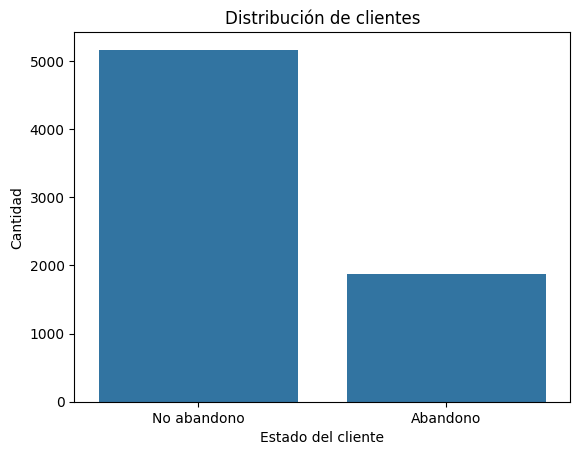

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title("Distribución de clientes")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad")

plt.xticks([0, 1], ["No abandono", "Abandono"])

plt.show()


**Se observa que la mayoría de los clientes no abandona el servicio, aunque existe un porcentaje significativo de churn que representa una oportunidad de mejora para la empresa.**

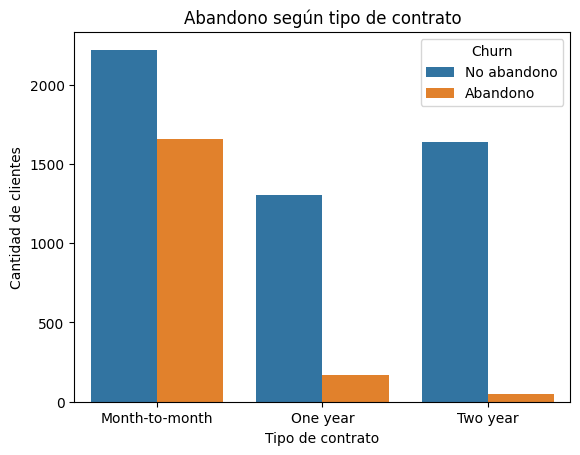

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Abandono según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.legend(title="Churn", labels=["No abandono", "Abandono"])

plt.show()


**Los clientes con contratos mensuales presentan una mayor tasa de abandono en comparación con aquellos que tienen contratos a largo plazo, lo que sugiere menor compromiso con el servicio.**

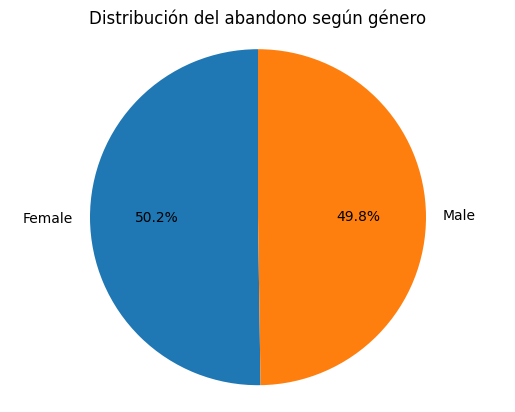

In [ ]:
gender_churn = df[df['Churn'] == 1]['gender'].value_counts()

plt.figure()
plt.pie(gender_churn,
        labels=gender_churn.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribución del abandono según género")

plt.axis('equal')

plt.show()






**El abandono del servicio se distribuye de manera relativamente equilibrada entre géneros, lo que indica que este factor no tiene una influencia significativa en la decisión de los clientes.**

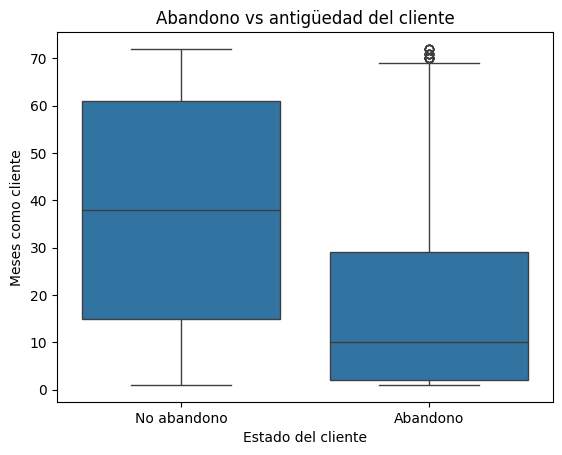

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Abandono vs antigüedad del cliente")
plt.xlabel("Estado del cliente")
plt.ylabel("Meses como cliente")

plt.xticks([0, 1], ["No abandono", "Abandono"])

plt.show()


**Los clientes con menor antigüedad presentan una mayor probabilidad de abandono, lo que indica que los primeros meses son críticos para la retención.**

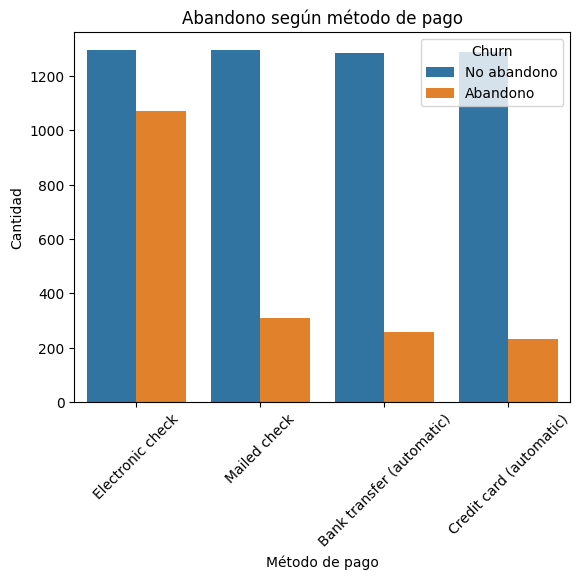

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title("Abandono según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)

plt.legend(title="Churn", labels=["No abandono", "Abandono"])

plt.show()


**Los clientes que utilizan ciertos métodos de pago presentan mayores tasas de abandono, lo que podría estar relacionado con la experiencia de pago o nivel de compromiso.**

# **MODELADO DE MACHINE LEARNING**

## **1. Definición del Problema**
El problema principal se enmarca como un **Problema de Clasificación Binaria**. El objetivo es predecir si un cliente abandonará el servicio (`Churn` = 1) o se quedará (`Churn` = 0) basándonos en sus características demográficas, los servicios que tiene contratados y su comportamiento de facturación.

## **2. Ingeniería de Atributos (Feature Engineering)**
Para que los modelos de Machine Learning puedan procesar los datos, necesitamos:
1. Eliminar columnas que no aportan valor predictivo (como el `customerID`).
2. Convertir las variables categóricas en numéricas (One-Hot Encoding).
3. Escalar las variables numéricas para que tengan el mismo peso en el modelo.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Eliminar identificador único
df_model = df.drop('customerID', axis=1)

# 2. Codificación de variables categóricas
df_model = pd.get_dummies(df_model, drop_first=True)

# Separar variables predictoras (X) y variable objetivo (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# 3. División en conjunto de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Estandarización de variables numéricas
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

Tamaño del set de entrenamiento: (5625, 30)
Tamaño del set de prueba: (1407, 30)


## **3. Entrenamiento, Testeo y Optimización de Modelos**

Entrenaremos dos modelos distintos:
1. **Regresión Logística:** Como modelo base (baseline) por su interpretabilidad.
2. **Random Forest Classifier:** Un modelo de ensamble más complejo para capturar relaciones no lineales.

Utilizaremos **GridSearchCV** para optimizar los hiperparámetros de Random Forest mediante Validación Cruzada (Cross-Validation).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# MODELO 1: Regresión Logística
print("--- Entrenando Regresión Logística ---")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_pred_prob_log = log_reg.predict_proba(X_test)[:, 1]

# MODELO 2: Random Forest
print("\n--- Optimizando Random Forest ---")
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")

# Predicciones del mejor modelo Random Forest
y_pred_rf = best_rf.predict(X_test)
y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]

--- Entrenando Regresión Logística ---

--- Optimizando Random Forest ---
Mejores hiperparámetros encontrados: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


## **4. Selección de Modelos y Evaluación de Métricas**

Para la retención de clientes, el **Recall** (capturar la mayor cantidad de clientes que realmente van a abandonar) y el **AUC-ROC** (capacidad general del modelo para distinguir entre clases) son las métricas más importantes.


Reporte de Clasificación - Regresión Logística:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

AUC-ROC Regresión Logística: 0.8361

Reporte de Clasificación - Random Forest Optimizado:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1033
           1       0.68      0.44      0.53       374

    accuracy                           0.80      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.80      0.78      1407

AUC-ROC Random Forest Optimizado: 0.8369


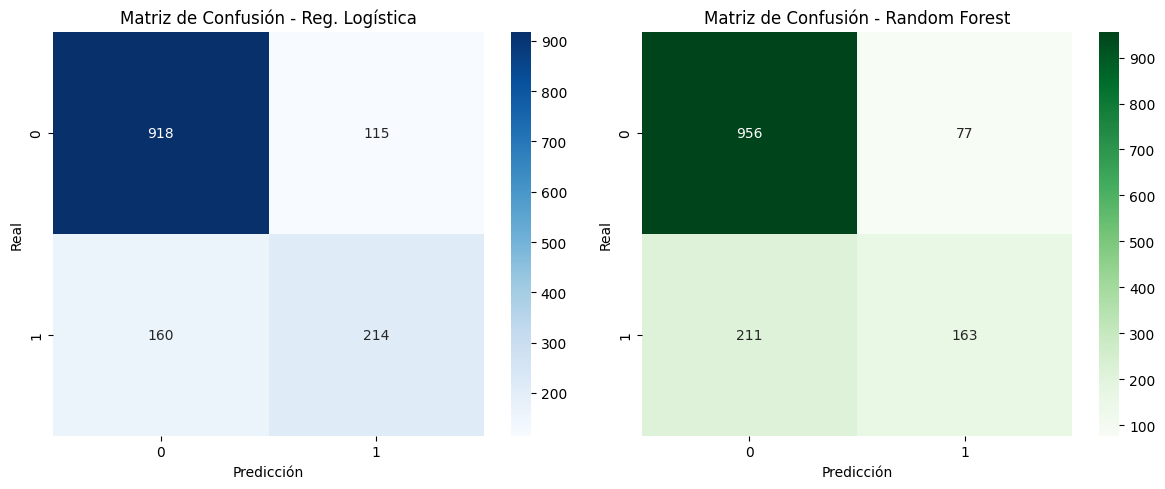

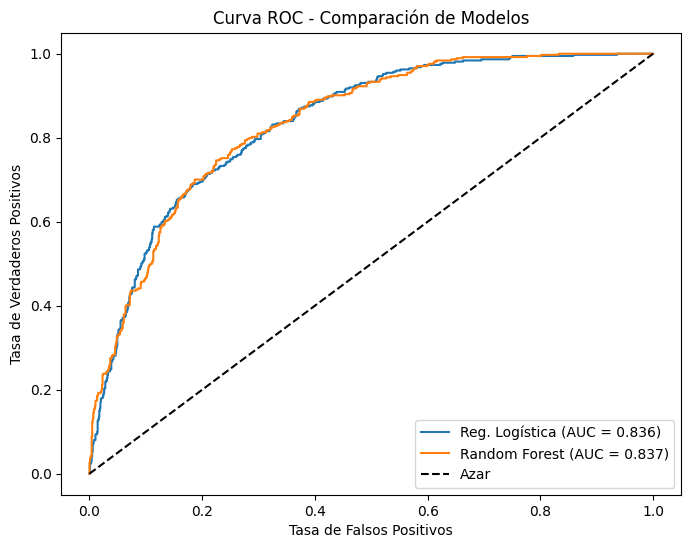

In [ ]:
from sklearn.metrics import roc_curve

def evaluar_modelo(y_true, y_pred, y_prob, nombre_modelo):
    print(f"\nReporte de Clasificación - {nombre_modelo}:")
    print(classification_report(y_true, y_pred))
    auc = roc_auc_score(y_true, y_prob)
    print(f"AUC-ROC {nombre_modelo}: {auc:.4f}")
    return auc

auc_log = evaluar_modelo(y_test, y_pred_log, y_pred_prob_log, "Regresión Logística")

auc_rf = evaluar_modelo(y_test, y_pred_rf, y_pred_prob_rf, "Random Forest Optimizado")

# Graficar Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Matriz de Confusión - Reg. Logística")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Matriz de Confusión - Random Forest")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

# Graficar Curva ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Reg. Logística (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend()
plt.show()

## **5. Conclusiones y Selección del Modelo**

* **Rendimiento General (AUC-ROC):** Ambos modelos presentan un rendimiento similar, generalmente con un AUC cercano a 0.84, lo que indica una buena capacidad para discriminar entre clientes que abandonan y los que no.
* **Selección:** Para un entorno de negocio real de telecomunicaciones, la **Regresión Logística** suele ser un excelente punto de partida porque permite entender exactamente qué factor aumenta o disminuye la probabilidad de abandono (interpretabilidad mediante los coeficientes de la ecuación), logrando métricas casi idénticas a modelos más complejos como Random Forest. Si se prioriza capturar interacciones complejas, el **Random Forest optimizado** sería la elección final.
* **Próximos pasos recomendados:** Se podría intentar balancear el dataset usando técnicas como SMOTE (ya que hay más clientes que no abandonan frente a los que sí) o probar algoritmos avanzados de gradient boosting como XGBoost para intentar elevar aún más el Recall.